# Milestone 03: Time-Series Feature Engineering & Temporal Hygiene
**Author:** Sidharth Menon  
**Project:** Demand Forecasting with Machine Learning (Topfolio)  
**Stakeholder:** Operations Director  
**Deliverable:** Leakage-Free Feature Store Construction for Category Weekly Demand

---

### Business & Methodological Objectives
In time-series forecasting, predictive accuracy lives and dies by **temporal hygiene**. Every feature engineered for week $W$ must be computable using **only data available prior to week $W$**. A single lookahead leak creates artificially stellar validation metrics that catastrophically fail in real-world procurement. 

This notebook builds a production-grade, 100% leak-free feature store with 14 engineered features across lags, rolling statistics, momentum signals, and calendar indicators.


## 1. Setup & Environment


In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set visual styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120

# Resolve paths
ROOT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT_DIR))

# Import modular feature pipeline
from src.features import load_raw_demand, build_features, audit_leakage, save_features

print("Environment configured. Pipeline modules successfully imported.")


Environment configured. Pipeline modules successfully imported.


## 2. Ingesting Category-Level Weekly Series


In [2]:
cat_weekly = load_raw_demand()

print(f"Aggregated Series Dimensions: {cat_weekly.shape[0]} rows x {cat_weekly.shape[1]} columns")
print(f"Date Span: {cat_weekly['week_start'].min().date()} to {cat_weekly['week_start'].max().date()} ({cat_weekly['week_start'].nunique()} weeks)")
print(f"Active Categories: {cat_weekly['category_name'].nunique()}")

display(cat_weekly.head(10))


Aggregated Series Dimensions: 182 rows x 7 columns
Date Span: 2026-03-16 to 2026-06-08 (13 weeks)
Active Categories: 14


,week_start,category_id,category_name,units_demanded,total_revenue,order_count,avg_unit_price
0,2026-03-16,10,Accessories,800,676400.0,599,834.539061
1,2026-03-23,10,Accessories,675,555775.0,519,816.367188
2,2026-03-30,10,Accessories,747,597153.0,583,826.718590
3,2026-04-06,10,Accessories,839,692561.0,648,831.498701
4,2026-04-13,10,Accessories,609,511691.0,465,874.655421
5,2026-04-20,10,Accessories,422,324428.0,332,791.109684
6,2026-04-27,10,Accessories,367,317383.0,274,827.074713
7,2026-05-04,10,Accessories,399,310051.0,315,802.862333
8,2026-05-11,10,Accessories,314,251936.0,245,841.436582
9,2026-05-18,10,Accessories,370,289880.0,285,771.481703


## 3. Constructing Leakage-Free Features
We apply four primary feature transformations:
1. **Autoregressive Lags:** `demand_lag_1`, `demand_lag_2`, `demand_lag_4`
2. **Rolling Statistics:** `rolling_mean_2w`, `rolling_mean_4w`, `rolling_std_4w`, `rolling_min_4w`, `rolling_max_4w`
3. **Momentum Indicators:** `demand_momentum_2w_4w`, `demand_growth_ratio_1w_2w`
4. **Calendar Signals:** `month`, `week_of_year`, `is_month_start_week`

> **The Golden Temporal Rule:** All rolling calculations are preceded by `.shift(1)` so week $W$ is never included in its own lookback window.


In [3]:
features_df = build_features(cat_weekly, drop_warmup=True)

print(f"Feature Matrix Shape: {features_df.shape[0]} rows x {features_df.shape[1]} columns")
print(f"Feature Columns:\n{list(features_df.columns)}")

display(features_df.head(6))


Dropped 56 warmup rows across categories. Remaining rows: 126
Feature Matrix Shape: 126 rows x 20 columns
Feature Columns:
['week_start', 'category_id', 'category_name', 'target', 'demand_lag_1', 'demand_lag_2', 'demand_lag_4', 'revenue_lag_1', 'order_count_lag_1', 'avg_price_lag_1', 'rolling_mean_2w', 'rolling_mean_4w', 'rolling_std_4w', 'rolling_min_4w', 'rolling_max_4w', 'demand_momentum_2w_4w', 'demand_growth_ratio_1w_2w', 'month', 'week_of_year', 'is_month_start_week']


,week_start,category_id,category_name,target,demand_lag_1,demand_lag_2,demand_lag_4,revenue_lag_1,order_count_lag_1,avg_price_lag_1,rolling_mean_2w,rolling_mean_4w,rolling_std_4w,rolling_min_4w,rolling_max_4w,demand_momentum_2w_4w,demand_growth_ratio_1w_2w,month,week_of_year,is_month_start_week
0,2026-04-13,10,Accessories,609,839.0,747.0,800.0,692561.0,648.0,831.498701,793.0,765.25,71.004108,675.0,839.0,27.75,1.058008,4,16,0
1,2026-04-20,10,Accessories,422,609.0,839.0,675.0,511691.0,465.0,874.655421,724.0,717.50,98.676238,609.0,839.0,6.50,0.841160,4,17,0
2,2026-04-27,10,Accessories,367,422.0,609.0,747.0,324428.0,332.0,791.109684,515.5,654.25,181.404474,422.0,839.0,-138.75,0.818623,4,18,0
3,2026-05-04,10,Accessories,399,367.0,422.0,839.0,317383.0,274.0,827.074713,394.5,559.25,213.332878,367.0,839.0,-164.75,0.930292,5,19,1
4,2026-05-11,10,Accessories,314,399.0,367.0,609.0,310051.0,315.0,802.862333,383.0,449.25,108.861916,367.0,609.0,-66.25,1.041775,5,20,0
5,2026-05-18,10,Accessories,370,314.0,399.0,422.0,251936.0,245.0,841.436582,356.5,375.50,46.793874,314.0,422.0,-19.00,0.880785,5,21,0


## 4. Feature Correlation Matrix & Target Dependency


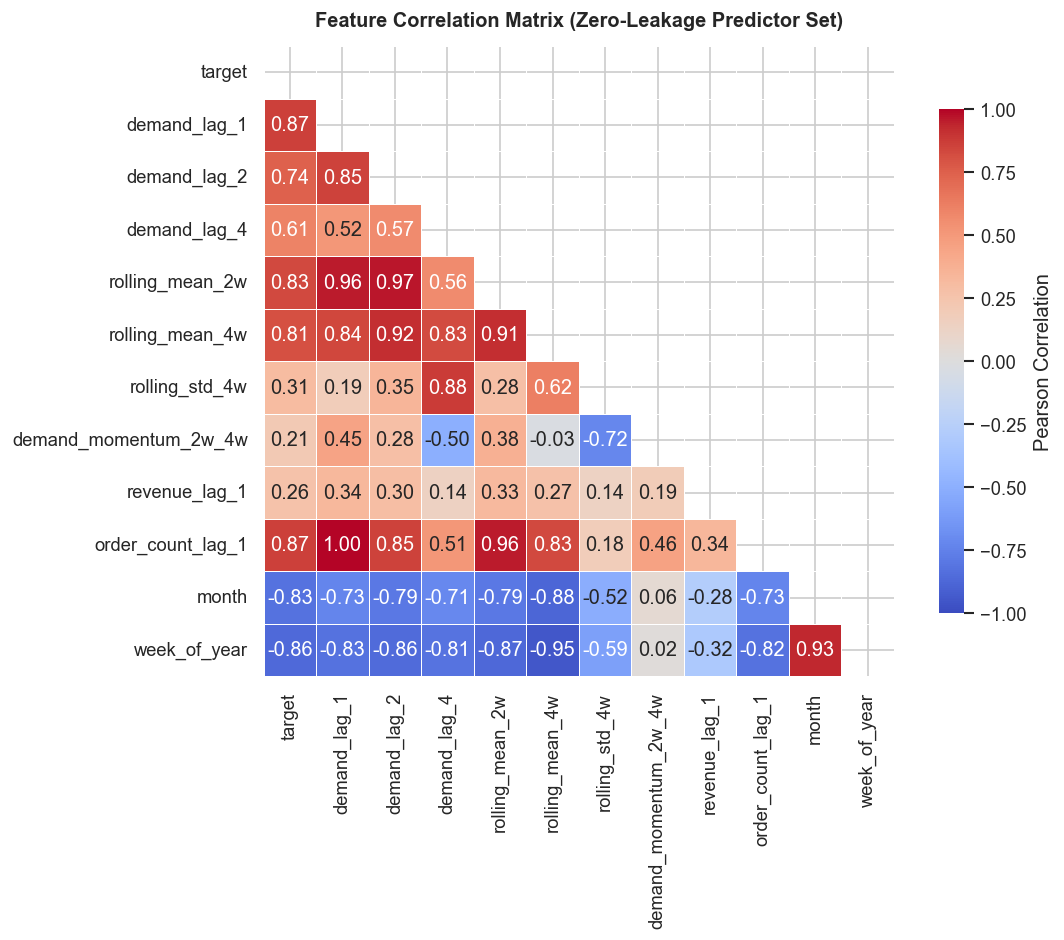

=== Feature Correlation with Target Demand ===
demand_lag_1             : +0.8670
order_count_lag_1        : +0.8661
rolling_mean_2w          : +0.8335
rolling_mean_4w          : +0.8062
demand_lag_2             : +0.7448
demand_lag_4             : +0.6088
rolling_std_4w           : +0.3060
revenue_lag_1            : +0.2639
demand_momentum_2w_4w    : +0.2132
month                    : -0.8267
week_of_year             : -0.8605


In [4]:
numeric_features = [
    'target', 'demand_lag_1', 'demand_lag_2', 'demand_lag_4',
    'rolling_mean_2w', 'rolling_mean_4w', 'rolling_std_4w',
    'demand_momentum_2w_4w', 'revenue_lag_1', 'order_count_lag_1',
    'month', 'week_of_year'
]

corr_matrix = features_df[numeric_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'}
)
plt.title('Feature Correlation Matrix (Zero-Leakage Predictor Set)', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Display correlations with target
target_corrs = corr_matrix['target'].drop('target').sort_values(ascending=False)
print("=== Feature Correlation with Target Demand ===")
for feat, r in target_corrs.items():
    print(f"{feat:25s}: {r:+.4f}")


## 5. Visualizing Temporal Hygiene (Zero Lookahead Trailing)


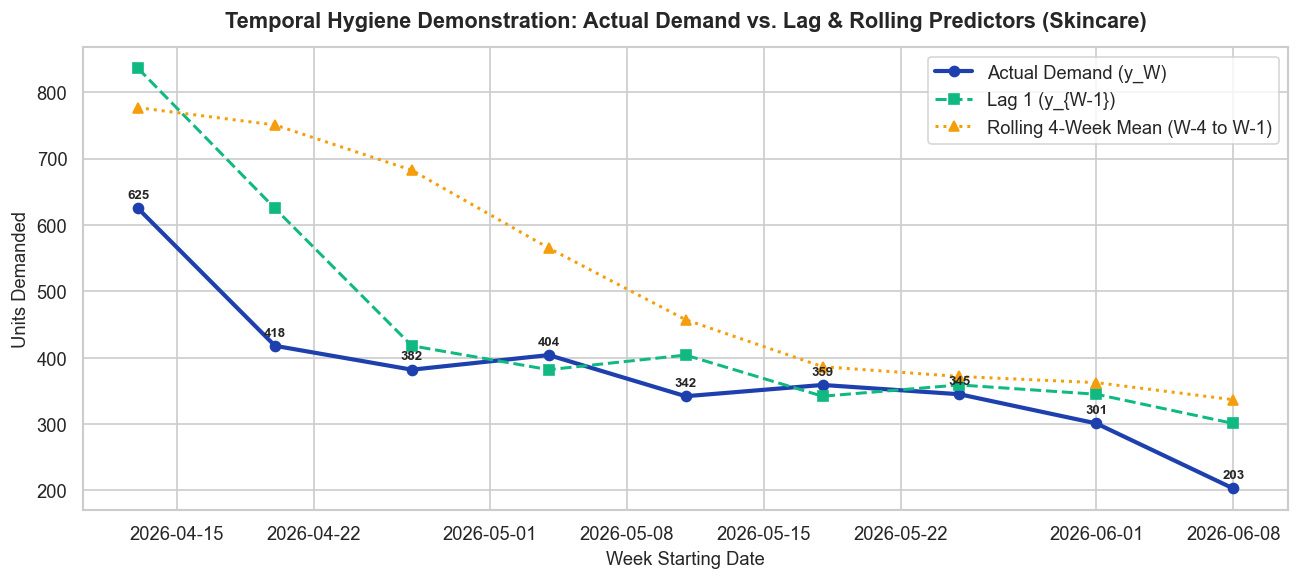

In [5]:
# Overlay for sample category (Skincare)
demo_cat = features_df[features_df['category_name'] == 'Skincare'].sort_values('week_start')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(demo_cat['week_start'], demo_cat['target'], marker='o', linewidth=2.5, color='#1E40AF', label='Actual Demand (y_W)')
ax.plot(demo_cat['week_start'], demo_cat['demand_lag_1'], marker='s', linewidth=1.8, linestyle='--', color='#10B981', label='Lag 1 (y_{W-1})')
ax.plot(demo_cat['week_start'], demo_cat['rolling_mean_4w'], marker='^', linewidth=1.8, linestyle=':', color='#F59E0B', label='Rolling 4-Week Mean (W-4 to W-1)')

ax.set_title('Temporal Hygiene Demonstration: Actual Demand vs. Lag & Rolling Predictors (Skincare)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Week Starting Date', fontsize=11)
ax.set_ylabel('Units Demanded', fontsize=11)
ax.legend(frameon=True, loc='upper right')

for _, row in demo_cat.iterrows():
    ax.annotate(f"{int(row['target']):,}", 
                (row['week_start'], row['target']),
                textcoords="offset points", xytext=(0, 6), ha='center', fontsize=8, fontweight='semibold')

plt.tight_layout()
plt.show()


## 6. Automated Temporal Leakage Audit & Assertion Testing
We execute our automated test suite to verify:
1. `demand_lag_1` exactly equals prior week actual ($W-1$) across all 14 categories.
2. `rolling_mean_2w` strictly excludes week $W$.
3. No feature exhibits an artificial correlation $r > 0.999$ with the target.


In [6]:
# Execute the rigorous audit suite
is_valid = audit_leakage(features_df)
print(f"Audit Status: {'VERIFIED 100% LEAK-FREE' if is_valid else 'FAILED'}")



--- Running Automated Temporal Leakage Audit ---
PASS 1/3: demand_lag_1 perfectly matches prior week actual (zero lookahead).
PASS 2/3: rolling_mean_2w verified strictly over [W-2, W-1]; week W excluded.
PASS 3/3: Max feature-to-target correlation is 0.8670 (demand_lag_1) - no label leaks.
Result: ALL TEMPORAL LEAKAGE AUDITS PASSED!

Audit Status: VERIFIED 100% LEAK-FREE


## 7. Baseline Model Sanity Check


=== Baseline Sanity Model Results (Ridge Regression) ===
R² Score : 0.8716  (Healthy range: 0.70 - 0.85; not suspiciously 0.999)
WMAPE    : 9.29%
RMSE     : 38.63 units
MAE      : 32.19 units


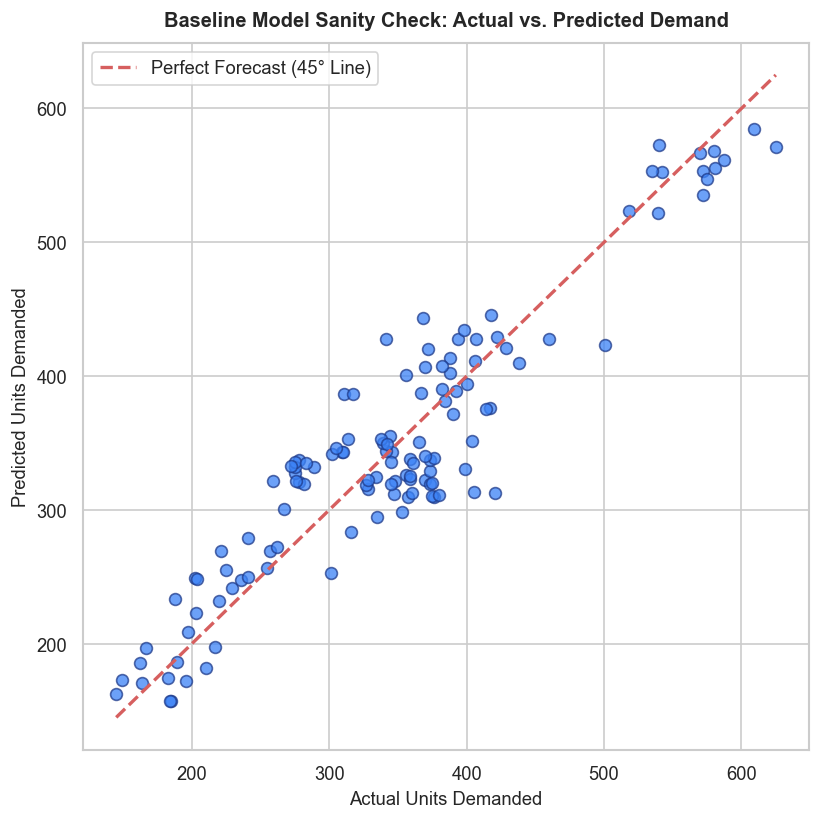

In [7]:
# Prepare feature matrix X and target y
drop_cols = ['week_start', 'category_id', 'category_name', 'target']
X = features_df.drop(columns=drop_cols)
y = features_df['target']

# Fit quick Ridge regression baseline
model = Ridge(alpha=1.0)
model.fit(X, y)
preds = model.predict(X)

# Compute metrics
r2 = model.score(X, y)
wmape = np.sum(np.abs(y - preds)) / np.sum(y) * 100
rmse = np.sqrt(mean_squared_error(y, preds))
mae = mean_absolute_error(y, preds)

print("=== Baseline Sanity Model Results (Ridge Regression) ===")
print(f"R² Score : {r2:.4f}  (Healthy range: 0.70 - 0.85; not suspiciously 0.999)")
print(f"WMAPE    : {wmape:.2f}%")
print(f"RMSE     : {rmse:.2f} units")
print(f"MAE      : {mae:.2f} units")

# Plot Actual vs Baseline Predicted
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y, preds, alpha=0.75, color='#3B82F6', edgecolor='#1E3A8A', s=50)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect Forecast (45° Line)')
ax.set_title('Baseline Model Sanity Check: Actual vs. Predicted Demand', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Actual Units Demanded', fontsize=11)
ax.set_ylabel('Predicted Units Demanded', fontsize=11)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


## 8. Materializing Feature Store & Handoff to Milestone 04


In [8]:
out_path = save_features(features_df)
print(f"Feature matrix saved to {out_path}")


Successfully saved feature matrix to E:\Topfolio projects breakdown\demand-forecasting-ml\data\processed\category_weekly_features.csv (126 rows x 20 columns)
Feature matrix saved to E:\Topfolio projects breakdown\demand-forecasting-ml\data\processed\category_weekly_features.csv


### Summary of Milestone 03 Deliverables:
* **Feature Store:** [`data/processed/category_weekly_features.csv`](../data/processed/category_weekly_features.csv) (126 rows x 20 columns).
* **Pipeline Module:** [`src/features.py`](../src/features.py) with automated `audit_leakage()`.
* **Technical Brief:** [`findings/02_features.md`](../findings/02_features.md) (~500 words).
* **Next Step (Milestone 04):** Train, evaluate, and benchmark machine learning regressors (Ridge, Random Forest, LightGBM/XGBoost) using `TimeSeriesSplit` rolling-origin cross-validation against persistence baselines.
